# QNN: hybrid quantum-classical classifier (PennyLane)

A small **simulated quantum circuit** acts as one layer inside a Keras network, followed by ordinary dense layers.

**Task (same as the other notebooks):** given one sensor's last 2 hours (24 × 5-min readings of flow, occupancy and
speed), predict whether its flow in the next 5 minutes will be **Low**, **Medium** or **High**.

| Step | What happens |
|---|---|
| 1 | Load the data and draw a training subsample |
| 2 | Compress each 72-number window to 6 features (PCA) and map them to rotation angles |
| 3 | Define the 6-qubit circuit and wrap it as a Keras layer |
| 4 | Train the hybrid QNN, with early stopping on a validation set |
| 5 | Train a **classical control**: identical, but with a normal dense layer instead of the circuit |
| 6 | Evaluate both on the full test set and compare with the baselines, ANN and CNN |
| 7 | Save the weights and results |

**Why a subsample?** The circuit is simulated on a normal CPU, which is far slower than a dense layer. Training on all
2.2 million windows would take days, so the QNN trains on a random 50,000-window subset. Testing still uses the
**full** test set, so its scores are directly comparable with every other model.

## 0 · Setup

In [ ]:
import json
import logging
import os
import time
import warnings
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, jaccard_score)
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", message=".*TensorFlow interface.*")
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# Config & Paths
PROJECT = r"E:\Traffic Flow Detection Using Neural Networks"

DATA_DIR    = os.path.join(PROJECT, "data")
MODELS_DIR  = os.path.join(PROJECT, "models")
RESULTS_DIR = os.path.join(PROJECT, "results")

for folder in (DATA_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(folder, exist_ok=True)

DATA_FILE        = os.path.join(DATA_DIR, "traffic_flow_preprocessed.npz")
BASELINE_FILE    = os.path.join(RESULTS_DIR, "baseline_results.json")
OTHER_MODELS     = {"ANN": os.path.join(RESULTS_DIR, "ann_results.json"),
                    "1-D CNN": os.path.join(RESULTS_DIR, "cnn_results.json")}
WEIGHTS_FILE     = os.path.join(MODELS_DIR, "qnn.weights.h5")
RESULTS_FILE     = os.path.join(RESULTS_DIR, "qnn_results.json")
PREDICTIONS_FILE = os.path.join(RESULTS_DIR, "qnn_predictions.npz")

CLASS_NAMES = ["Low", "Medium", "High"]
N_QUBITS = 6
N_LAYERS = 3
TRAIN_SAMPLES = 50_000   # random subsample of the fit period
VAL_SAMPLES = 10_000     # random subsample of the validation period
VAL_FRAC = 0.10          # last 10 % of the training period -> validation
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 2e-3
PATIENCE = 3
SEED = 42

keras.utils.set_random_seed(SEED)
print("PennyLane", qml.__version__, "| TensorFlow", tf.__version__)

PennyLane 0.45.1 | TensorFlow 2.21.0


## 1 · Load the data and draw the subsample

Same data and chronological split as the ANN and CNN: the last 10 % of the training period is for validation,
the test set is the last 20 % of the timeline.

The subsample is **random within each period**, so it still covers all sensors and times of day, but it never
mixes periods. Validation windows are still later than training windows, and test windows are later still.

In [ ]:
d = np.load(DATA_FILE)
X_train_all = d["X_train_seq"].reshape(len(d["X_train_seq"]), -1)   # (samples, 72)
X_test = d["X_test_seq"].reshape(len(d["X_test_seq"]), -1)
y_train_all = d["y_train"].astype(np.int32)
y_test = d["y_test"].astype(np.int32)
time_train, sensor_test = d["time_train"], d["sensor_test"]

val_start = np.quantile(time_train, 1 - VAL_FRAC)
fit_idx = np.where(time_train < val_start)[0]
val_idx = np.where(time_train >= val_start)[0]

rng = np.random.default_rng(SEED)
fit_idx = rng.choice(fit_idx, size=min(TRAIN_SAMPLES, len(fit_idx)), replace=False)
val_idx = rng.choice(val_idx, size=min(VAL_SAMPLES, len(val_idx)), replace=False)

X_fit, y_fit = X_train_all[fit_idx], y_train_all[fit_idx]
X_val, y_val = X_train_all[val_idx], y_train_all[val_idx]

print(f"Fit: {len(X_fit):,}   Validation: {len(X_val):,}   Test: {len(X_test):,} (full)")
print("Fit class share:", np.round(np.bincount(y_fit) / len(y_fit), 3))

Fit: 50,000   Validation: 10,000   Test: 606,390 (full)
Fit class share: [0.33  0.334 0.336]


## 2 · From 72 numbers to 6 rotation angles

A 6-qubit circuit takes **6 inputs**, one rotation angle per qubit, so each 72-number window must be compressed.

1. **PCA (72 → 6):** keeps the 6 directions along which the windows vary the most. For traffic, the first components
   are roughly "overall level" and "recent trend". The printout shows how much of the information they keep.
2. **Scale to [0, π]:** each input becomes an **RX rotation angle**. The range 0 to π covers a qubit's full swing
   from |0⟩ to |1⟩, so different inputs give clearly different quantum states.
3. **Clip:** validation and test values can fall slightly outside the training range, so they are clipped to [0, π].

Both steps are fitted on the training subsample only.

In [ ]:
pca = PCA(n_components=N_QUBITS, random_state=SEED).fit(X_fit)
scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(pca.transform(X_fit))

def to_angles(X):
    return np.clip(scaler.transform(pca.transform(X)), 0, np.pi).astype(np.float32)

A_fit, A_val = to_angles(X_fit), to_angles(X_val)
print(f"PCA keeps {pca.explained_variance_ratio_.sum():.1%} of the variance "
      f"(per component: {np.round(pca.explained_variance_ratio_, 3)})")
print("Angle-encoded shapes:", A_fit.shape, A_val.shape)

PCA keeps 92.8% of the variance (per component: [0.695 0.131 0.052 0.019 0.017 0.014])
Angle-encoded shapes: (50000, 6) (10000, 6)


## 3 · The quantum circuit

```
qubit 0: ─RX(x₀)─╭─────────────────────╮─ ⟨Z⟩ → output 0
qubit 1: ─RX(x₁)─│  Strongly           │─ ⟨Z⟩ → output 1
   …             │  entangling layers  │   …
qubit 5: ─RX(x₅)─╰──── (× 3) ──────────╯─ ⟨Z⟩ → output 5
         encoding   trainable part        measurement
```

* **Angle embedding:** each input angle rotates one qubit (`RX`). This loads the data into the quantum state.
* **Strongly entangling layers (× 3):** each layer rotates every qubit by 3 trainable angles, then links neighbouring
  qubits with CNOT gates so they become entangled. These **54 angles (3 × 6 × 3) are the circuit's trainable weights**,
  like the weights of a dense layer.
* **Measurement:** the expectation value ⟨Z⟩ of each qubit, a number between −1 and +1. These 6 numbers are the
  layer's output.

`default.qubit` simulates the circuit exactly on the CPU. `diff_method="backprop"` lets TensorFlow compute gradients
through the simulation, just as for any other layer.

In [ ]:
dev = qml.device("default.qubit", wires=N_QUBITS)


@qml.qnode(dev, interface="tf", diff_method="backprop")
def circuit(inputs, weights):
    # inputs: (batch, N_QUBITS). PennyLane runs the whole batch at once ("parameter broadcasting").
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="X")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


print(qml.draw(circuit, level="device", decimals=None)(np.zeros(N_QUBITS), np.zeros((N_LAYERS, N_QUBITS, 3))))

0: ──RX──Rot─╭●─────────────╭X──Rot─╭●──────────╭X──Rot──────╭●───────╭X───────┤  <Z>
1: ──RX──Rot─╰X─╭●──────────│───Rot─│──╭●───────│──╭X────Rot─│──╭●────│──╭X────┤  <Z>
2: ──RX──Rot────╰X─╭●───────│───Rot─╰X─│──╭●────│──│─────Rot─│──│──╭●─│──│──╭X─┤  <Z>
3: ──RX──Rot───────╰X─╭●────│───Rot────╰X─│──╭●─│──│─────Rot─╰X─│──│──╰●─│──│──┤  <Z>
4: ──RX──Rot──────────╰X─╭●─│───Rot───────╰X─│──╰●─│─────Rot────╰X─│─────╰●─│──┤  <Z>
5: ──RX──Rot─────────────╰X─╰●──Rot──────────╰X────╰●────Rot───────╰X───────╰●─┤  <Z>


### Wrapping the circuit as a Keras layer

Two details matter here, and the old notebook got both wrong:

1. **The weights must be created with `add_weight`.** The old code created a plain `tf.Variable` in `__init__`.
   Keras 3 doesn't register that as a layer weight, so the old model summary showed **0 parameters** for the quantum
   layer. The optimiser never updated it, and the circuit stayed random for the whole training run.
2. **The circuit should run on a whole batch at once.** The old code looped over samples one by one with
   `tf.map_fn`, which is why an epoch took 20–80 minutes. PennyLane can simulate a batch in one call.

`tf.py_function` runs the PennyLane simulation eagerly inside the Keras graph. The quantum weights are passed in as an
input, so gradients flow back to them.

In [ ]:
class QuantumLayer(layers.Layer):
    def __init__(self, n_qubits=N_QUBITS, n_layers=N_LAYERS, **kwargs):
        super().__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        self.q_weights = self.add_weight(
            name="q_weights",
            shape=(self.n_layers, self.n_qubits, 3),
            initializer=keras.initializers.RandomUniform(0.0, 2 * np.pi, seed=SEED),
            trainable=True,
        )

    def call(self, inputs):
        def run_circuit(x, w):
            # This runs outside the notebook's warning filters, so silence the
            # PennyLane deprecation notice here as well.
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                expvals = circuit(x, w)
            # ⟨Z⟩ values are real; drop the zero imaginary part before casting.
            return tf.cast(tf.math.real(tf.stack(expvals, axis=-1)), tf.float32)

        out = tf.py_function(run_circuit, [inputs, self.q_weights], tf.float32)
        out.set_shape((None, self.n_qubits))
        return out

    def get_config(self):
        return {**super().get_config(), "n_qubits": self.n_qubits, "n_layers": self.n_layers}

## 4 · The hybrid model

```
6 angles → QuantumLayer (6 qubits, 54 weights) → Dense 64 → Dropout 0.3 → Dense 32 → Dense 3 (softmax)
```

The dense head is the same as in the old notebook. `jit_compile=False` is required: `tf.py_function` can't be
compiled by XLA, TensorFlow's optimising compiler.

In [ ]:
def build_model(feature_layer, name):
    inputs = keras.Input(shape=(N_QUBITS,))
    x = feature_layer(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(3, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"], jit_compile=False)
    return model


qnn = build_model(QuantumLayer(name="quantum"), "qnn")
qnn.summary()   # the quantum layer must show 54 parameters, not 0

Model: "qnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quantum (QuantumLayer)          │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,681 (10.47 KB)

 Trainable params: 2,681 (10.47 KB)

 Non-trainable params: 0 (0.00 B)

## 5 · Train the QNN

Early stopping watches validation loss and restores the best epoch. The validation set is **not** the test set;
the old notebook used the test set here.

**How long it takes:** in testing, one epoch on 50,000 samples took about 5 minutes on a 2-core CPU (≈ 0.4 s per batch
of 64). With early stopping, expect 20–100 minutes in total, less on a faster machine. The time printed after training
shows the real figure. To try a quick run first, lower `TRAIN_SAMPLES` (e.g. to 10,000) in the config cell.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                           restore_best_weights=True)
start = time.time()
qnn_history = qnn.fit(A_fit, y_fit, validation_data=(A_val, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE,
                      callbacks=[early_stop], verbose=1)
qnn_minutes = (time.time() - start) / 60
qnn_best_epoch = int(np.argmin(qnn_history.history["val_loss"])) + 1
print(f"\nTrained {len(qnn_history.history['loss'])} epochs in {qnn_minutes:.1f} min; best epoch = {qnn_best_epoch}")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 230ms/step - accuracy: 0.7680 - loss: 0.5204 - val_accuracy: 0.8373 - val_loss: 0.3798
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 153s 195ms/step - accuracy: 0.8351 - loss: 0.3866 - val_accuracy: 0.8382 - val_loss: 0.3673
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 155s 198ms/step - accuracy: 0.8401 - loss: 0.3772 - val_accuracy: 0.8438 - val_loss: 0.3597
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 254ms/step - accuracy: 0.8415 - loss: 0.3738 - val_accuracy: 0.8434 - val_loss: 0.3577
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 293s 374ms/step - accuracy: 0.8440 - loss: 0.3690 - val_accuracy: 0.8470 - val_loss: 0.3541
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 202ms/step - accuracy: 0.8448 - loss: 0.3678 - val_accuracy: 0.8486 - val_loss: 0.3522
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 157s 201ms/step - accuracy: 0.8448 - loss: 0.3654 - val_accuracy: 0.8478 - val_loss: 0.3505
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 202ms/step - accuracy: 0.8462 -

## 6 · Classical control: does the circuit actually help?

A fair test of the quantum layer: build the **same** model with the circuit replaced by an ordinary
`Dense(6, tanh)` layer. It has the same inputs (the 6 angles), the same output size (6 values between −1 and +1, like ⟨Z⟩),
the same dense head, training subsample and early stopping.

* Control ≈ QNN → the circuit works as a feature layer but adds nothing beyond a classical one.
* QNN clearly better → the circuit contributes something. That would be a result worth highlighting.

This comparison is what a reviewer will ask for. It is also far more informative than comparing the QNN with the
full-data ANN, which sees 72 inputs and 44× more training data.

In [ ]:
keras.utils.set_random_seed(SEED)
control = build_model(layers.Dense(N_QUBITS, activation="tanh", name="classical_6"), "classical_control")

start = time.time()
control_history = control.fit(A_fit, y_fit, validation_data=(A_val, y_val),
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                                                       restore_best_weights=True)],
                              verbose=0)
print(f"Classical control trained {len(control_history.history['loss'])} epochs "
      f"in {(time.time() - start) / 60:.1f} min")

Classical control trained 20 epochs in 0.3 min


### Training curves

Solid lines: QNN. Dashed: classical control.

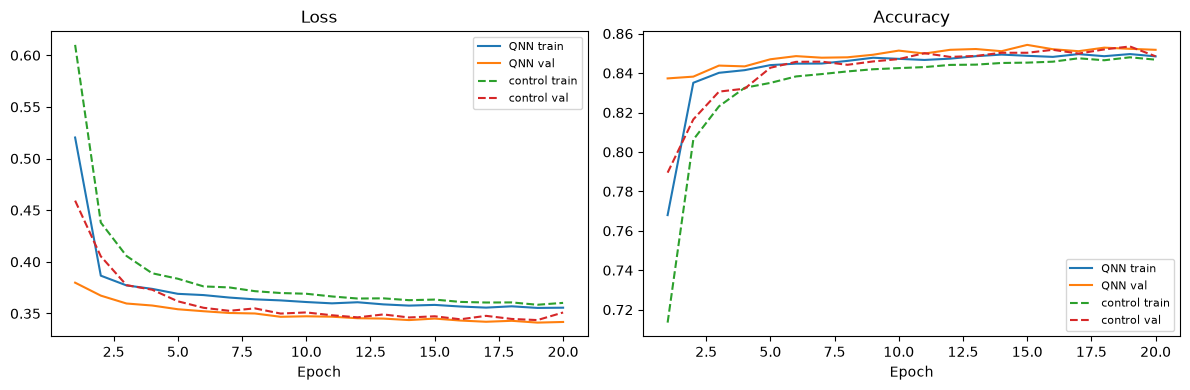

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ["loss", "accuracy"]):
    for hist, label, style in [(qnn_history, "QNN", "-"), (control_history, "control", "--")]:
        ep = range(1, len(hist.history[key]) + 1)
        ax.plot(ep, hist.history[key], style, label=f"{label} train")
        ax.plot(ep, hist.history[f"val_{key}"], style, label=f"{label} val")
    ax.set_xlabel("Epoch"); ax.set_title(key.capitalize()); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7 · Evaluate on the full test set

Both models are scored on all ≈ 606k test windows. Large prediction batches keep this fast: the circuit simulates
thousands of samples per call.

In [ ]:
A_test = to_angles(X_test)

start = time.time()
qnn_prob = qnn.predict(A_test, batch_size=8192, verbose=0)
print(f"QNN prediction on {len(A_test):,} samples took {(time.time() - start) / 60:.1f} min")
control_prob = control.predict(A_test, batch_size=8192, verbose=0)

y_pred = qnn_prob.argmax(axis=1).astype(np.int32)
y_pred_control = control_prob.argmax(axis=1).astype(np.int32)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
iou = jaccard_score(y_test, y_pred, average=None)
acc_c = accuracy_score(y_test, y_pred_control)
f1_c = f1_score(y_test, y_pred_control, average="macro")

print(f"\nQNN               accuracy {acc:.4f}   macro-F1 {macro_f1:.4f}   mean IoU {iou.mean():.4f}")
print(f"Classical control accuracy {acc_c:.4f}   macro-F1 {f1_c:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

QNN prediction on 606,390 samples took 0.3 min

QNN               accuracy 0.8625   macro-F1 0.8625   mean IoU 0.7633
Classical control accuracy 0.8613   macro-F1 0.8610

              precision    recall  f1-score   support

         Low     0.9511    0.9330    0.9420    204308
      Medium     0.7792    0.8129    0.7957    198136
        High     0.8599    0.8401    0.8499    203946

    accuracy                         0.8625    606390
   macro avg     0.8634    0.8620    0.8625    606390
weighted avg     0.8642    0.8625    0.8632    606390



### Confusion matrix (QNN)

Row percentages. As with the other models, errors should sit next to the diagonal.

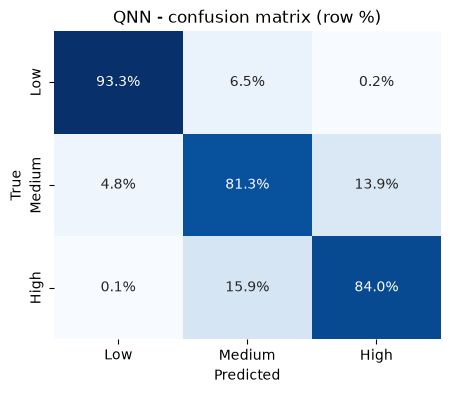

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("QNN - confusion matrix (row %)")
plt.show()

## 8 · Comparison with all models so far

The baselines, ANN and CNN are read from their saved result files. All are scored on the same test set, but note the
different training data: the ANN and CNN use all 72 inputs and the full 2.2 million training windows, the QNN and its
control use 6 PCA features and 50,000 windows.

In [ ]:
with open(BASELINE_FILE) as f:
    results = json.load(f)
for name, path in OTHER_MODELS.items():
    if os.path.exists(path):
        with open(path) as f:
            r = json.load(f)
        results[name] = {"accuracy": r["accuracy"], "macro_f1": r["macro_f1"]}
results["QNN (6 qubits)"] = {"accuracy": float(acc), "macro_f1": float(macro_f1)}
results["Classical control (6 units)"] = {"accuracy": float(acc_c), "macro_f1": float(f1_c)}

table = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
display(table.style.format("{:.4f}"))
print(f"QNN vs classical control: {(acc - acc_c) * 100:+.2f} points")
print(f"QNN vs 15-min average   : {(acc - results['15-min average']['accuracy']) * 100:+.2f} points")

,accuracy,macro_f1
1-D CNN,0.8918,0.8911
ANN,0.8899,0.8893
15-min average,0.8808,0.8804
Persistence,0.8728,0.8721
Logistic regression,0.8724,0.8717
QNN (6 qubits),0.8625,0.8625
Classical control (6 units),0.8613,0.8610
Linear trend,0.8066,0.8043
Majority class,0.3363,0.1678


QNN vs classical control: +0.12 points
QNN vs 15-min average   : -1.83 points


### How to read this

Fill this in after your run. It's worth checking three things:

1. **QNN vs classical control:** the fair test of the quantum layer.
2. **QNN vs the 15-min-average rule (≈ 88.1 %):** does it beat "traffic stays the same"?
3. **QNN vs ANN / CNN:** expect a gap, mostly because the QNN sees only 6 compressed features and 2 % of the data.
   That's a limit of simulating quantum circuits on a CPU, not necessarily of the circuit itself.

## 9 · Example predictions

Ten random test samples with the QNN's class probabilities.

In [ ]:
idx = np.sort(np.random.default_rng(SEED).choice(len(y_test), size=10, replace=False))
pd.DataFrame({
    "sensor": sensor_test[idx],
    "true": [CLASS_NAMES[i] for i in y_test[idx]],
    "predicted": [CLASS_NAMES[i] for i in y_pred[idx]],
    "P(Low)": qnn_prob[idx, 0].round(3),
    "P(Medium)": qnn_prob[idx, 1].round(3),
    "P(High)": qnn_prob[idx, 2].round(3),
})

,sensor,true,predicted,P(Low),P(Medium),P(High)
0,96,Medium,Medium,0.004,0.604,0.392
1,60,High,High,0.000,0.021,0.979
2,158,High,Medium,0.027,0.922,0.050
3,108,Low,Low,0.995,0.005,0.000
4,93,Low,Low,0.984,0.016,0.000
5,78,Low,Low,0.991,0.008,0.000
6,141,High,High,0.002,0.180,0.818
7,85,Low,Low,0.999,0.001,0.000
8,113,Low,Low,0.986,0.014,0.000
9,101,High,High,0.001,0.077,0.922


## 10 · Save

* `models/qnn.weights.h5`: the trained weights. The custom quantum layer uses `tf.py_function`, which can't be saved as a
  full `.keras` model. To reload, run the cells that define the circuit and `build_model`, then call
  `qnn.load_weights(WEIGHTS_FILE)`.
* `results/qnn_results.json`: scores for the QNN and its classical control, same format as the other models.
* `results/qnn_predictions.npz`: test predictions, probabilities and training history.

In [ ]:
qnn.save_weights(WEIGHTS_FILE)
with open(RESULTS_FILE, "w") as f:
    json.dump({"accuracy": float(acc), "macro_f1": float(macro_f1),
               "iou_per_class": iou.tolist(), "mean_iou": float(iou.mean()),
               "best_epoch": qnn_best_epoch, "train_samples": int(len(A_fit)),
               "train_minutes": round(qnn_minutes, 1),
               "classical_control": {"accuracy": float(acc_c), "macro_f1": float(f1_c)}}, f, indent=2)
np.savez(PREDICTIONS_FILE, y_true=y_test, y_pred=y_pred, y_prob=qnn_prob,
         y_pred_control=y_pred_control, sensor=sensor_test,
         **{f"history_{k}": np.array(v) for k, v in qnn_history.history.items()})
print("Saved:")
for path in (WEIGHTS_FILE, RESULTS_FILE, PREDICTIONS_FILE):
    print("  ", path)

Saved:
   E:\Traffic Flow Detection Using Neural Networks\models\qnn.weights.h5
   E:\Traffic Flow Detection Using Neural Networks\results\qnn_results.json
   E:\Traffic Flow Detection Using Neural Networks\results\qnn_predictions.npz
